In [1]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset, WeightedRandomSampler
import numpy as np
import math
import os
import copy
import pandas as pd
from torchvision.io import read_image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

In [2]:
# Check compute device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [3]:
split_rate = 0.8
batch_size = 32
epochs = 80
epochs_1 = 50
epochs_2 = 30
learning_rate = 0.005 # <0.05
learning_rate_1 = learning_rate * 0.1
learning_rate_2 = learning_rate * 0*1 *0.1
top_k_test = 1
weight_decay = 1.9e-2 #0.0001 - 0.01
momentum = 0
hidden_units = 64
IMG_SIZE = 224

In [4]:

train_data_path = "/kaggle/input/catdog-combined-dataset-hust2024/DogBreeds/DogBreeds/train"
val_data_path = "/kaggle/input/catdog-combined-dataset-hust2024/DogBreeds/DogBreeds/test"
#Transform images
train_data_transforms = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                    transforms.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0)), 
                                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                                    transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),
                                      transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
add_train_data_transforms_1 = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                    transforms.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0)), 
                                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                                      transforms.RandomRotation(degrees=(90,90)),
                                    transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),
                                      transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
add_train_data_transforms_2 = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                    transforms.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0)), 
                                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                                      transforms.RandomRotation(degrees=(180,180)),
                                    transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),
                                      transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
add_train_data_transforms_3 = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                    transforms.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0)), 
                                    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                                      transforms.RandomRotation(degrees=(270,270)),
                                    transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),
                                      transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
val_data_transforms = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                      transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])
#Load data
org_train_dataset = torchvision.datasets.ImageFolder(root=train_data_path, transform=train_data_transforms)
add_train_dataset_1 = torchvision.datasets.ImageFolder(root=train_data_path, transform=add_train_data_transforms_1)
add_train_dataset_2 = torchvision.datasets.ImageFolder(root=train_data_path, transform=add_train_data_transforms_2)
add_train_dataset_3 = torchvision.datasets.ImageFolder(root=train_data_path, transform=add_train_data_transforms_3)
val_dataset = torchvision.datasets.ImageFolder(root=val_data_path, transform=val_data_transforms)

train_dataset = ConcatDataset([org_train_dataset,add_train_dataset_1,add_train_dataset_2,add_train_dataset_3])
class_num = len(org_train_dataset.classes)
#Take small number of data
#dataset = torch.utils.data.Subset(original_dataset,range(int(0.2*len(dataset))))

#Split data at the same ratio for each class
#stratified_split = StratifiedShuffleSplit(n_splits=1, train_size=split_rate, random_state=42)
targets = np.array([label for _, label in train_dataset])
#for train_idx, val_idx in stratified_split.split(np.zeros(len(targets)), targets)
    #train_dataset = Subset(dataset, train_idx)
    #test_dataset = Subset(dataset, val_idx)

#Over sampling

class_sample_count = np.array([len(np.where(targets == t)[0]) for t in np.unique(targets)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in targets])


samples_weight = torch.from_numpy(samples_weight)
sampler = WeightedRandomSampler(samples_weight, len(samples_weight))
#Loader
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, num_workers= 4, sampler=sampler)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size = batch_size, shuffle=False, num_workers = 4)
#Print number of samples
print("Number of samples in training set: %d" % (len(train_dataset)))
print("Number of samples in validation set: %d" % (len(val_dataset)))
#Number of class
classes = {}
for i in range(class_num):
    classes[i] = org_train_dataset.classes[i]
print(classes)

Number of samples in training set: 26640
Number of samples in validation set: 1687
{0: 'n02085782-Japanese_spaniel', 1: 'n02085936-Maltese_dog', 2: 'n02086646-Blenheim_spaniel', 3: 'n02086910-papillon', 4: 'n02088094-Afghan_hound', 5: 'n02088466-bloodhound', 6: 'n02089078-black-and-tan_coonhound', 7: 'n02089973-English_foxhound', 8: 'n02091244-Ibizan_hound', 9: 'n02091467-Norwegian_elkhound', 10: 'n02092002-Scottish_deerhound', 11: 'n02092339-Weimaraner', 12: 'n02093647-Bedlington_terrier', 13: 'n02093754-Border_terrier', 14: 'n02093859-Kerry_blue_terrier', 15: 'n02095889-Sealyham_terrier', 16: 'n02096051-Airedale', 17: 'n02096294-Australian_terrier', 18: 'n02096437-Dandie_Dinmont', 19: 'n02096585-Boston_bull', 20: 'n02100236-German_short-haired_pointer', 21: 'n02101556-clumber', 22: 'n02102040-English_springer', 23: 'n02102177-Welsh_springer_spaniel', 24: 'n02102480-Sussex_spaniel', 25: 'n02104365-schipperke', 26: 'n02105505-komondor', 27: 'n02105641-Old_English_sheepdog', 28: 'n02105

In [5]:
def show_transformed_images(Dataset):
    loader = torch.utils.data.DataLoader(Dataset, batch_size = 6, shuffle=True)
    batch = next(iter(loader))
    images, labels = batch
    #show images after transform
    grid = torchvision.utils.make_grid(images, nrow = 3)

    plt.figure(figsize=(11, 11))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    print("Labels: ", labels)

Labels:  tensor([33, 12, 34,  7,  9,  1])


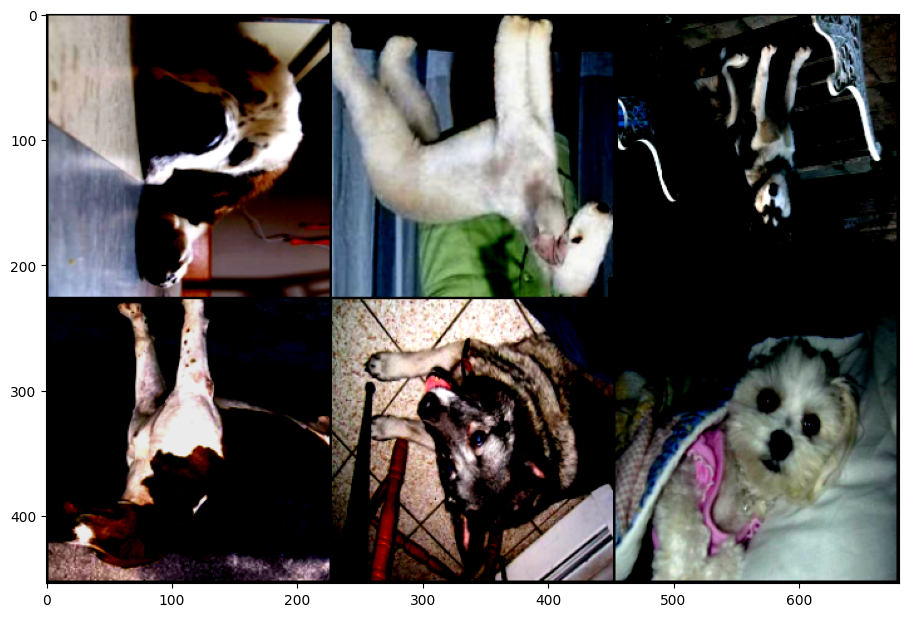

In [6]:
#Show some images
show_transformed_images(train_dataset)

In [7]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        #Block 1
        self.layer1 = nn.Sequential(

            nn.Conv2d(3, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU())
        self.layer2 = nn.Sequential(

            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        #Block 2
        self.layer3 = nn.Sequential(

            nn.Conv2d(hidden_units, hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU())
        self.layer4 = nn.Sequential(

            nn.Conv2d(hidden_units*2, hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        #Block 3
        self.layer5 = nn.Sequential(

            nn.Conv2d(hidden_units*2, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU())
        self.layer6 = nn.Sequential(

            nn.Conv2d(hidden_units*4, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.Conv2d(hidden_units*4, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        #Block 4
        self.layer7 = nn.Sequential(

            nn.Conv2d(hidden_units*4, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU())
        self.layer8 = nn.Sequential(

            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        #Block 5
        self.layer9 = nn.Sequential(

            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU())
        self.layer10 = nn.Sequential(

            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.Conv2d(hidden_units*8, hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        #Classifier
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(7*7*hidden_units*8, 8192),
            nn.ReLU())
        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(8192, 8192),
            nn.ReLU())
        self.fc2= nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(8192, class_num))






    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = self.layer6(out)
        out = self.layer7(out)
        out = self.layer8(out)
        out = self.layer9(out)
        out = self.layer10(out)

        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)

        return out
model = NeuralNetwork().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = weight_decay, momentum = momentum)

Total number of parameters: 287746158


In [8]:
def evaluate(model, test_dataloader,criterion):
    model.eval()
    corrects_per_epoch = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for data in test_dataloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            total += labels.size(0)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probabilities = torch.softmax(outputs, dim=1)
            _, predict = torch.topk(probabilities, k=top_k_test, dim=1)

            running_loss += loss.item()
            corrects_per_epoch += torch.sum(predict.eq(labels.view(-1, 1))).item()

    epoch_loss = running_loss/len(test_dataloader)
    epoch_acc = 100.00 * corrects_per_epoch / total
    print("Validation acc: %.3f%%, Validation loss: %.3f" % (epoch_acc, epoch_loss))
    return epoch_acc



In [9]:
def train_NN(model, train_dataloader, test_dataloader, criterion, optimizer, number_epochs):
    train_acc_list = []
    test_acc_list = []
    num_epochs = [i for i in range (number_epochs)]
    best_model = None
    for epoch in range(number_epochs):
        print("Epochs number %d" % (epoch + 1))
        model.train()
        running_loss = 0.0
        running_correct = 0.0
        total = 0
        for data in train_dataloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            #Backpropagation
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            #Loss and accuracy
            total += labels.size(0)
            _, predict = torch.max(outputs.data, 1)
            running_loss += loss.item()


            running_correct += (labels == predict).sum().item()
        epoch_loss = running_loss/len(train_dataloader)
        epoch_acc = 100.00 * running_correct / total
        print("Training complete. Got %d out of %d correctly (%.3f%%). Epoch loss: %.3f" % (running_correct, total, epoch_acc, epoch_loss))
        train_acc_list.append(epoch_acc)
        test_acc = evaluate(model, test_dataloader, criterion)
        test_acc_list.append(test_acc)
        print("Best acc:",round(max(test_acc_list),3),'%')
        if test_acc == max(test_acc_list):
            best_model = copy.deepcopy(model)

    torch.save(best_model.state_dict(), "My_model_with_%.3f%%.pth" % (max(test_acc_list)))
    print("Finished")
    plt.plot(num_epochs, np.array(train_acc_list), color = "r", label = "Train accuracy")
    plt.plot(num_epochs, np.array(test_acc_list), color = "b", label = "Validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy(%)")
    plt.title("Train accuracy vs Test accuracy")
    plt.legend()
    plt.show()
    #return model
    print("Evaluating best model on the test set...")
    all_labels, all_predictions = get_all_predictions(best_model, test_dataloader)
    print(classification_report(all_labels, all_predictions))
    return best_model,max(test_acc_list)

def get_all_predictions(model, dataloader):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for data in dataloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predict = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predict.cpu().numpy())

    return all_labels, all_predictions


Epochs number 1
Training complete. Got 1419 out of 26640 correctly (5.327%). Epoch loss: 3.678
Validation acc: 11.025%, Validation loss: 3.390
Best acc: 11.025 %
Epochs number 2
Training complete. Got 3237 out of 26640 correctly (12.151%). Epoch loss: 3.231
Validation acc: 14.464%, Validation loss: 3.198
Best acc: 14.464 %
Epochs number 3
Training complete. Got 4661 out of 26640 correctly (17.496%). Epoch loss: 2.958
Validation acc: 8.477%, Validation loss: 4.685
Best acc: 14.464 %
Epochs number 4
Training complete. Got 6031 out of 26640 correctly (22.639%). Epoch loss: 2.738
Validation acc: 25.548%, Validation loss: 2.654
Best acc: 25.548 %
Epochs number 5
Training complete. Got 7625 out of 26640 correctly (28.622%). Epoch loss: 2.495
Validation acc: 19.324%, Validation loss: 3.081
Best acc: 25.548 %
Epochs number 6
Training complete. Got 9101 out of 26640 correctly (34.163%). Epoch loss: 2.280
Validation acc: 16.301%, Validation loss: 3.482
Best acc: 25.548 %
Epochs number 7
Training

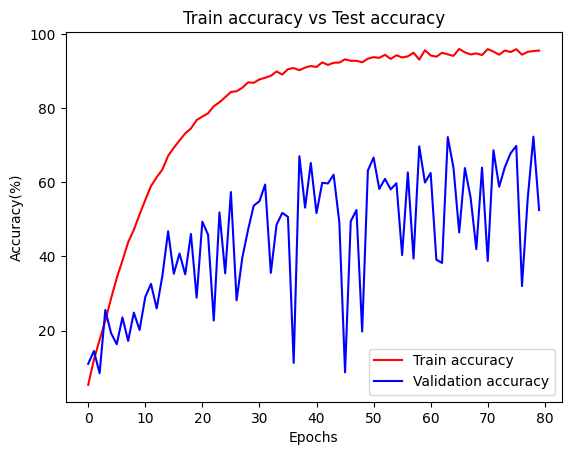

Evaluating best model on the test set...
              precision    recall  f1-score   support

           0       0.78      0.76      0.77        37
           1       0.69      0.65      0.67        51
           2       0.73      0.71      0.72        38
           3       0.73      0.75      0.74        40
           4       0.63      0.77      0.69        48
           5       0.95      0.55      0.70        38
           6       0.70      0.44      0.54        32
           7       1.00      0.47      0.64        32
           8       0.82      0.71      0.76        38
           9       0.63      0.85      0.72        40
          10       0.43      0.85      0.57        47
          11       0.85      0.69      0.76        32
          12       0.75      0.81      0.78        37
          13       0.72      0.74      0.73        35
          14       0.67      0.78      0.72        36
          15       0.62      0.83      0.71        41
          16       0.89      0.41      0

In [10]:
best_model,best_acc = train_NN(model, train_dataloader, val_dataloader, loss_fn, optimizer, epochs)

Epochs number 1
Training complete. Got 26490 out of 26640 correctly (99.437%). Epoch loss: 0.066
Validation acc: 83.580%, Validation loss: 0.611
Best acc: 83.58 %
Epochs number 2
Training complete. Got 26598 out of 26640 correctly (99.842%). Epoch loss: 0.042
Validation acc: 83.580%, Validation loss: 0.598
Best acc: 83.58 %
Epochs number 3
Training complete. Got 26613 out of 26640 correctly (99.899%). Epoch loss: 0.037
Validation acc: 83.580%, Validation loss: 0.593
Best acc: 83.58 %
Epochs number 4
Training complete. Got 26614 out of 26640 correctly (99.902%). Epoch loss: 0.036
Validation acc: 84.351%, Validation loss: 0.583
Best acc: 84.351 %
Epochs number 5
Training complete. Got 26627 out of 26640 correctly (99.951%). Epoch loss: 0.035
Validation acc: 84.647%, Validation loss: 0.585
Best acc: 84.647 %
Epochs number 6
Training complete. Got 26628 out of 26640 correctly (99.955%). Epoch loss: 0.033
Validation acc: 84.884%, Validation loss: 0.582
Best acc: 84.884 %
Epochs number 7
Tra

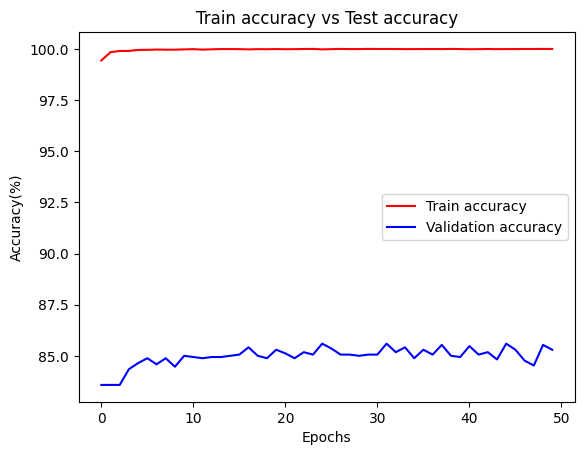

Evaluating best model on the test set...
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        37
           1       0.80      0.84      0.82        51
           2       0.76      0.82      0.78        38
           3       0.91      0.80      0.85        40
           4       0.80      0.90      0.84        48
           5       0.89      0.82      0.85        38
           6       0.75      0.84      0.79        32
           7       0.96      0.75      0.84        32
           8       0.75      0.87      0.80        38
           9       0.78      0.80      0.79        40
          10       0.82      0.85      0.83        47
          11       0.91      0.94      0.92        32
          12       0.90      0.95      0.92        37
          13       0.89      0.91      0.90        35
          14       0.77      0.92      0.84        36
          15       0.89      0.80      0.85        41
          16       0.90      0.85      0

In [11]:
best_model_copy = copy.deepcopy(best_model)
optimizer_1 = torch.optim.SGD(best_model_copy.parameters(), lr=learning_rate_1, weight_decay = weight_decay, momentum = momentum)
best_model_1,best_acc_1 = train_NN(best_model_copy, train_dataloader, val_dataloader, loss_fn, optimizer_1, epochs_1)

Epochs number 1
Training complete. Got 26640 out of 26640 correctly (100.000%). Epoch loss: 0.042
Validation acc: 85.536%, Validation loss: 0.607
Best acc: 85.536 %
Epochs number 2
Training complete. Got 26638 out of 26640 correctly (99.992%). Epoch loss: 0.043
Validation acc: 85.062%, Validation loss: 0.597
Best acc: 85.536 %
Epochs number 3
Training complete. Got 26639 out of 26640 correctly (99.996%). Epoch loss: 0.042
Validation acc: 85.418%, Validation loss: 0.599
Best acc: 85.536 %
Epochs number 4
Training complete. Got 26639 out of 26640 correctly (99.996%). Epoch loss: 0.042
Validation acc: 85.418%, Validation loss: 0.604
Best acc: 85.536 %
Epochs number 5
Training complete. Got 26636 out of 26640 correctly (99.985%). Epoch loss: 0.043
Validation acc: 85.181%, Validation loss: 0.603
Best acc: 85.536 %
Epochs number 6
Training complete. Got 26639 out of 26640 correctly (99.996%). Epoch loss: 0.042
Validation acc: 84.825%, Validation loss: 0.607
Best acc: 85.536 %
Epochs number 7

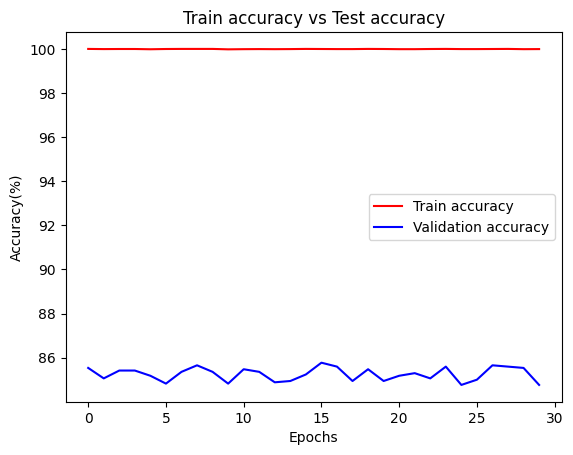

Evaluating best model on the test set...
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        37
           1       0.78      0.84      0.81        51
           2       0.76      0.82      0.78        38
           3       0.87      0.82      0.85        40
           4       0.91      0.90      0.91        48
           5       0.94      0.79      0.86        38
           6       0.73      0.84      0.78        32
           7       0.93      0.78      0.85        32
           8       0.73      0.84      0.78        38
           9       0.75      0.82      0.79        40
          10       0.78      0.83      0.80        47
          11       0.85      0.91      0.88        32
          12       0.85      0.95      0.90        37
          13       0.92      0.94      0.93        35
          14       0.86      0.89      0.88        36
          15       0.92      0.80      0.86        41
          16       0.86      0.88      0

In [12]:
if best_acc_1 > best_acc:
    best_model_1_copy = copy.deepcopy(best_model_1)
else:
    best_model_1_copy = copy.deepcopy(best_model)
optimizer_2 = torch.optim.SGD(best_model_1_copy.parameters(), lr=learning_rate_2, weight_decay = weight_decay, momentum = momentum)
best_model_2,best_acc_2 = train_NN(best_model_1_copy, train_dataloader, val_dataloader, loss_fn, optimizer_2, epochs_2)

In [13]:
print(f"Best Accuracy after first training: {best_acc:.3f}%")
print(f"Best Accuracy after second training: {best_acc_1:.3f}%")
print(f"Best Accuracy after final training: {best_acc_2:.3f}%")

Best Accuracy after first training: 72.318%
Best Accuracy after second training: 85.596%
Best Accuracy after final training: 85.774%
